Memproses plotting gabungan 12 hari...
✅ Proses pembuatan gambar gabungan selesai


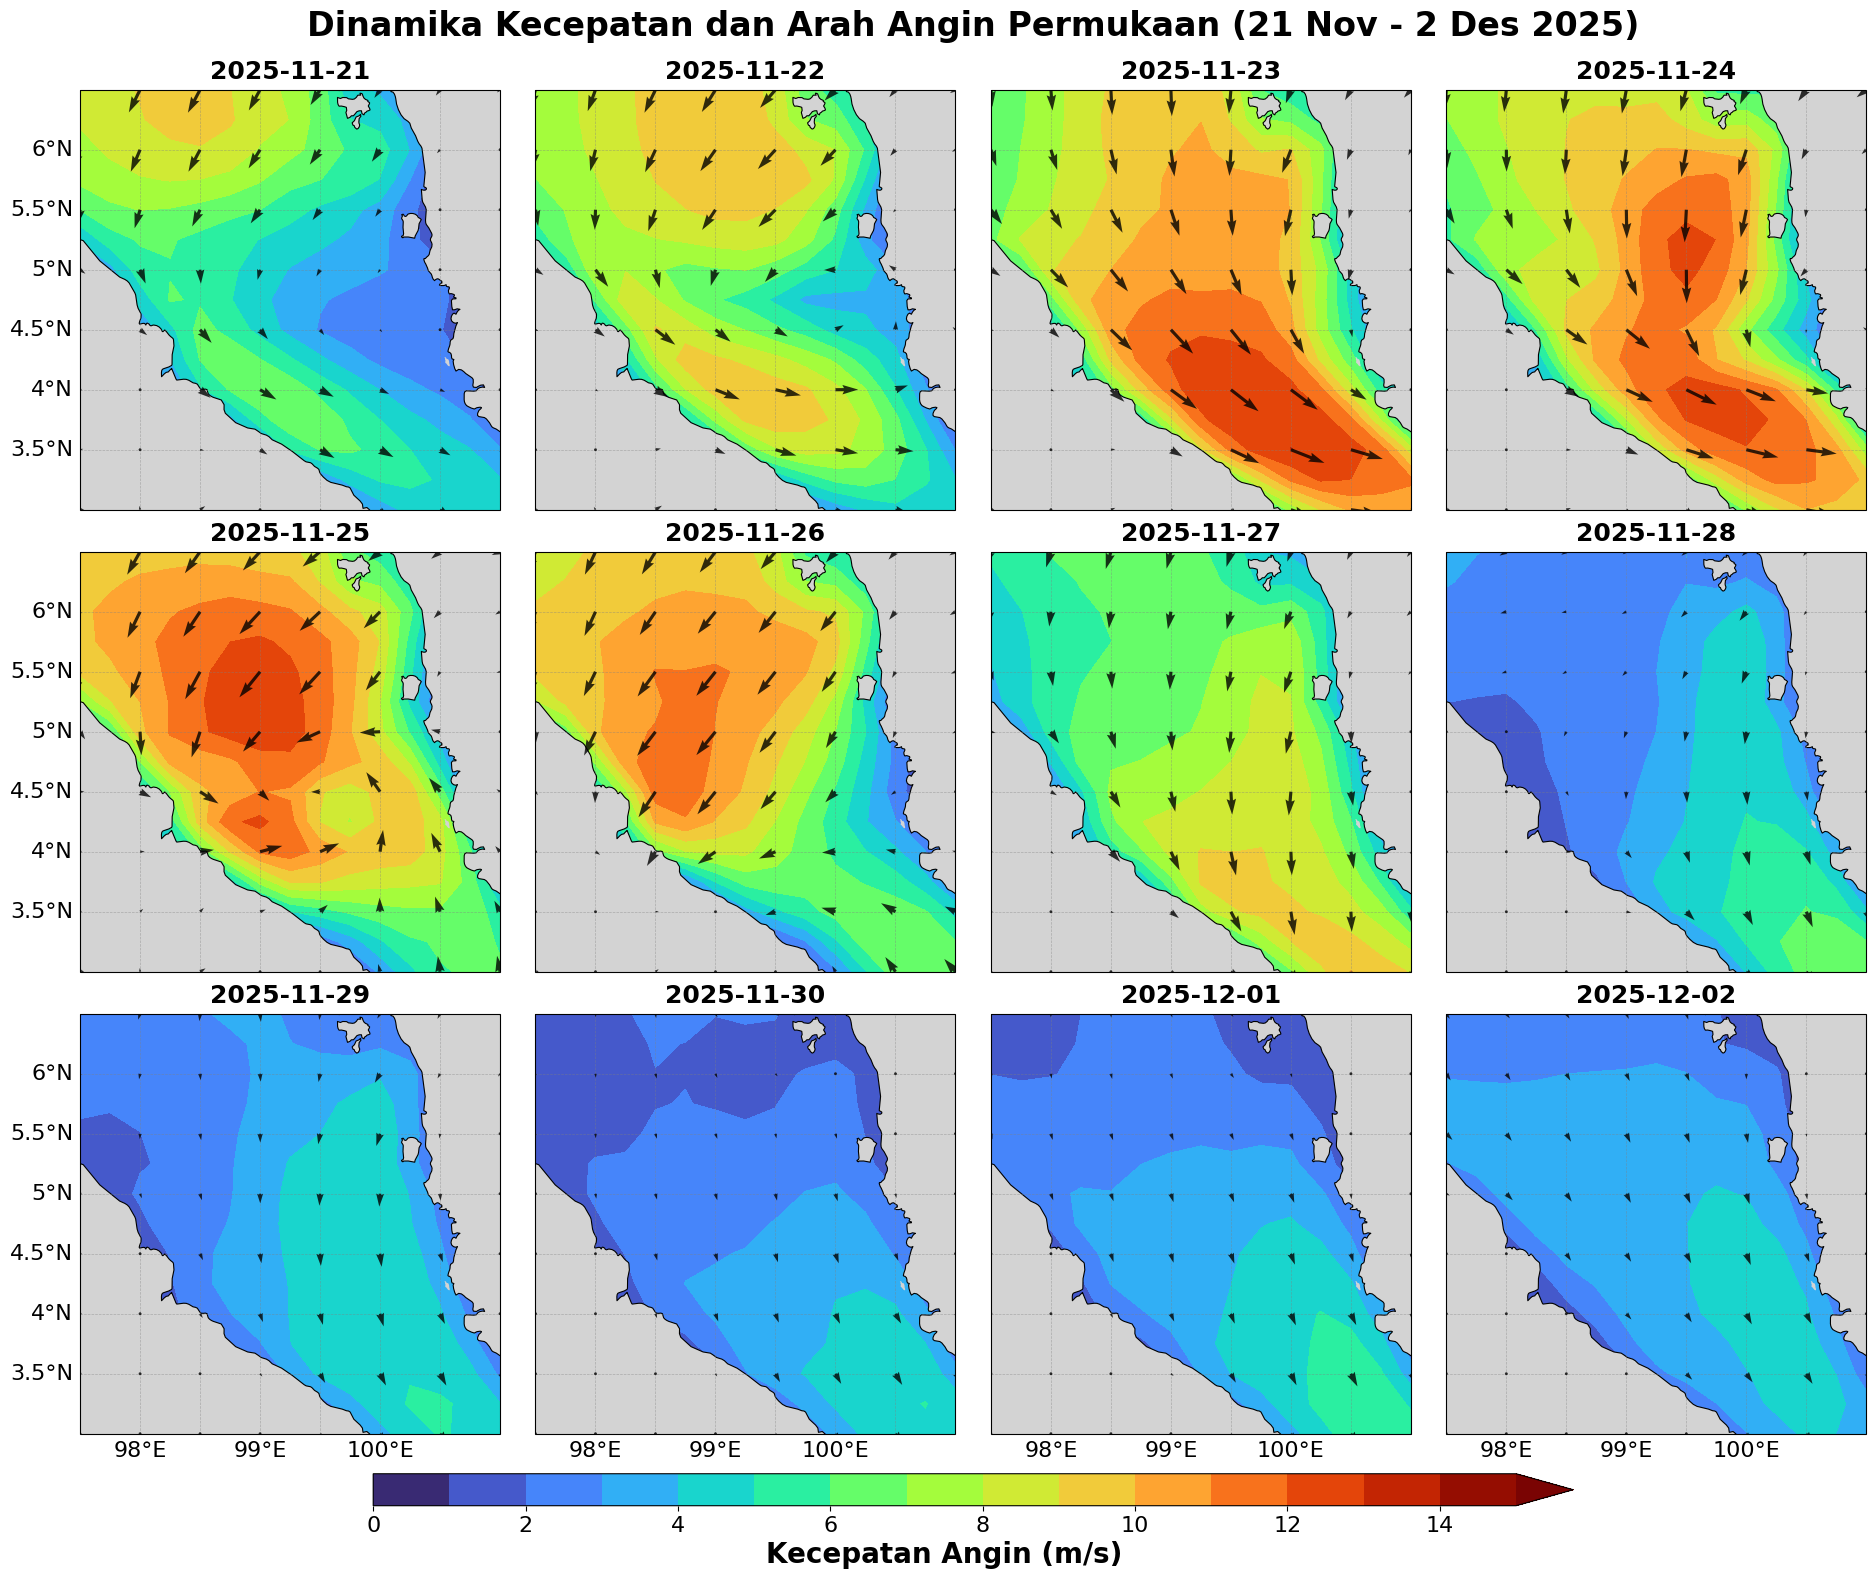

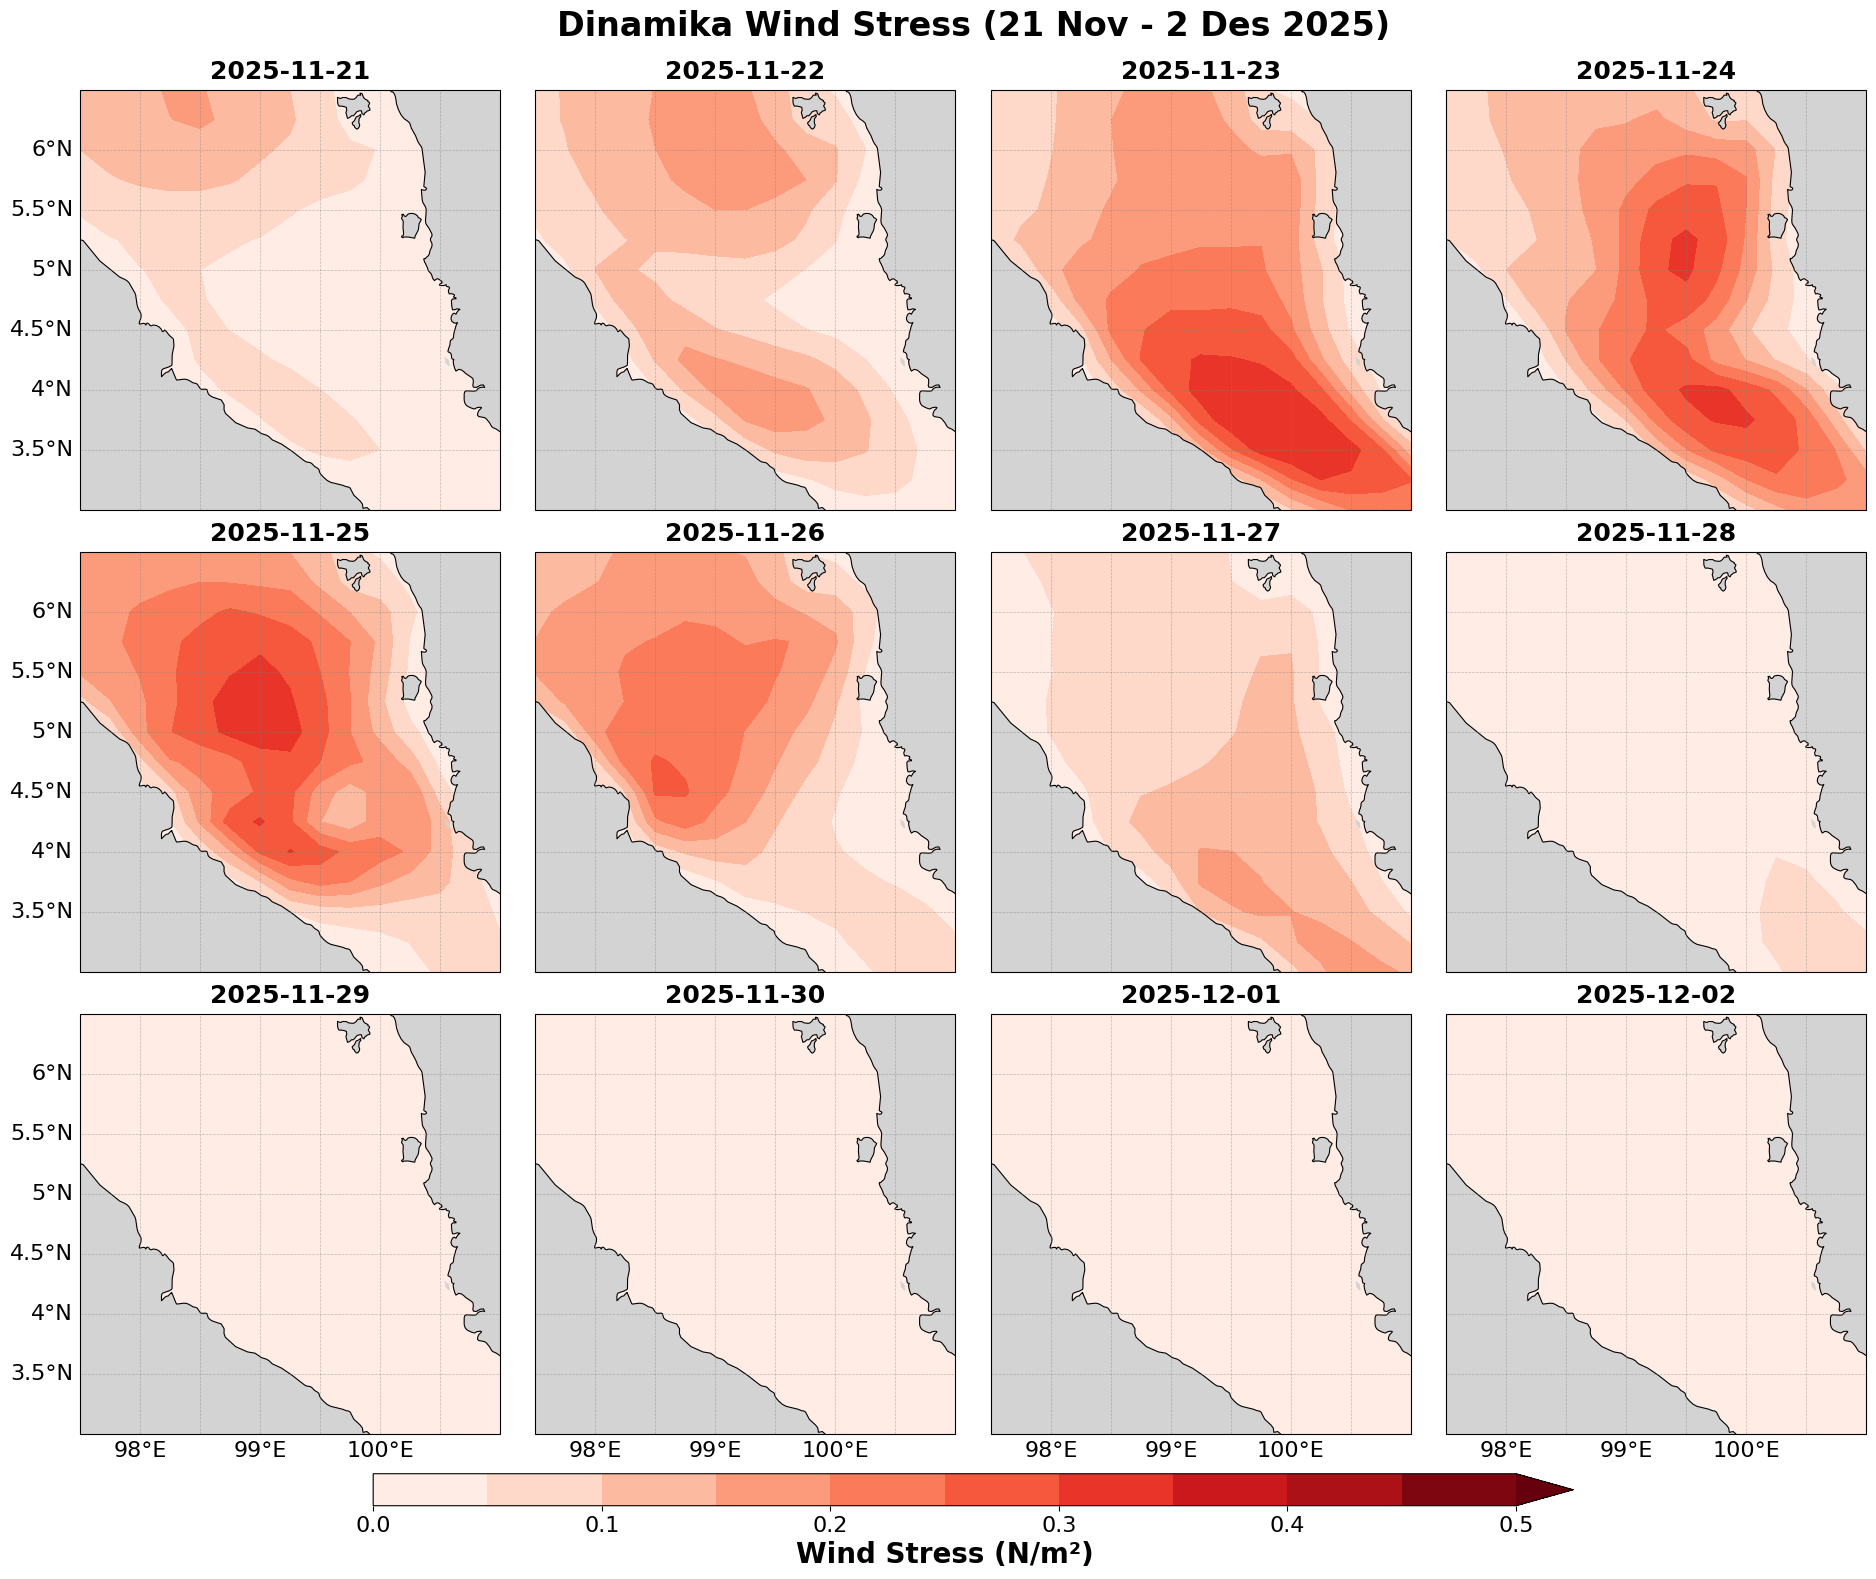

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# 1. LOAD DATA & CROP SPASIAL + WAKTU
file_nc = r"D:\Kuliah\Skripsi\Olah data\Data_Angin.nc"
ds = xr.open_dataset(file_nc)

lon_min, lon_max = 97.5, 101.0
lat_max, lat_min = 6.5, 3.0

# Pemotongan Spasial
ds_crop = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))

# Pemotongan Waktu (12 Hari: 21 Nov - 2 Des 2025)
waktu_awal = '2025-11-21'
waktu_akhir = '2025-12-02'
ds_crop = ds_crop.sel(valid_time=slice(waktu_awal, waktu_akhir))

# 2. EKSTRAKSI & PERHITUNGAN FISIKA (HOURLY)
u10 = ds_crop['u10']
v10 = ds_crop['v10']

# Kecepatan Angin
ws = np.sqrt(u10**2 + v10**2)

# Wind Stress
rho_air = 1.225
Cd = (0.8 + 0.065 * ws) * 1e-3

tau_x = rho_air * Cd * ws * u10
tau_y = rho_air * Cd * ws * v10
tau_mag = np.sqrt(tau_x**2 + tau_y**2)

# Simpan ke dataset
ds_crop = ds_crop.assign(ws=ws, tau_x=tau_x, tau_y=tau_y, tau_mag=tau_mag)

# 3. RESAMPLING HARIAN
ds_daily = ds_crop.resample(valid_time='1D').mean(dim='valid_time')

lon = ds_daily['longitude'].values
lat = ds_daily['latitude'].values
X, Y = np.meshgrid(lon, lat)

skip = (slice(None, None, 2), slice(None, None, 2)) 

# 4. PERSIAPAN FIGURE GABUNGAN
fig_ws, axes_ws = plt.subplots(3, 4, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes_ws_flat = axes_ws.flatten()

fig_tau, axes_tau = plt.subplots(3, 4, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes_tau_flat = axes_tau.flatten()

# --- FUNGSI FORMAT PETA & GRIDLINES ---
def format_map(ax, title, i):
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    if i % 4 != 0: 
        gl.left_labels = False   
    if i < 8:      
        gl.bottom_labels = False 
        
    gl.xlabel_style = {'size': 16, 'color': 'black'}
    gl.ylabel_style = {'size': 16, 'color': 'black'}
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=8)

# 5. LOOPING PLOTTING KE SETIAP PANEL
print("Memproses plotting gabungan 12 hari...")

for i, time_val in enumerate(ds_daily.valid_time.values):
    date_str = pd.to_datetime(time_val).strftime('%Y-%m-%d')
    
    ds_day = ds_daily.isel(valid_time=i)
    u_day = ds_day['u10'].values
    v_day = ds_day['v10'].values
    ws_day = ds_day['ws'].values
    tau_x_day = ds_day['tau_x'].values
    tau_y_day = ds_day['tau_y'].values
    tau_mag_day = ds_day['tau_mag'].values
    
    # --- ISI PANEL KECEPATAN ANGIN (fig_ws) ---
    ax_w = axes_ws_flat[i]
    cf_ws = ax_w.contourf(X, Y, ws_day, levels=np.linspace(0, 15, 16), cmap='turbo', extend='max', transform=ccrs.PlateCarree(), zorder=0)
    ax_w.quiver(X[skip], Y[skip], u_day[skip], v_day[skip], color='black', alpha=0.8, scale=150, transform=ccrs.PlateCarree(), zorder=3)
    format_map(ax_w, f'{date_str}', i)
    
    # --- ISI PANEL WIND STRESS (fig_tau) ---
    ax_t = axes_tau_flat[i]
    cf_tau = ax_t.contourf(X, Y, tau_mag_day, levels=np.linspace(0, 0.5, 11), cmap='Reds', extend='max', transform=ccrs.PlateCarree(), zorder=0)
    #ax_t.quiver(X[skip], Y[skip], tau_x_day[skip], tau_y_day[skip], color='black', alpha=0.8, scale=12, transform=ccrs.PlateCarree(), zorder=3)
    format_map(ax_t, f'{date_str}', i)

# 6. TAMBAHKAN 1 COLORBAR GLOBAL & SIMPAN
fig_ws.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08, wspace=0.05, hspace=0.1)
fig_tau.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08, wspace=0.05, hspace=0.1)

# --- COLORBAR KECEPATAN ANGIN ---
cbar_ax_ws = fig_ws.add_axes([0.2, 0.035, 0.6, 0.02]) 
cbar_ws = fig_ws.colorbar(cf_ws, cax=cbar_ax_ws, orientation='horizontal')

cbar_ws.set_label('Kecepatan Angin (m/s)', fontsize=20, fontweight='bold')
cbar_ws.ax.tick_params(labelsize=16)

fig_ws.suptitle('Dinamika Kecepatan dan Arah Angin Permukaan (21 Nov - 2 Des 2025)', fontsize=24, fontweight='bold', y=0.97)
fig_ws.savefig(r"D:\Kuliah\Skripsi\Olah data\Kecepatan_Angin_Gabungan_12Hari.png", dpi=600, bbox_inches='tight', facecolor='white')

# --- COLORBAR WIND STRESS ---
cbar_ax_tau = fig_tau.add_axes([0.2, 0.035, 0.6, 0.02])
cbar_tau = fig_tau.colorbar(cf_tau, cax=cbar_ax_tau, orientation='horizontal')

cbar_tau.set_label('Wind Stress (N/m²)', fontsize=20, fontweight='bold')
cbar_tau.ax.tick_params(labelsize=16)

fig_tau.suptitle('Dinamika Wind Stress (21 Nov - 2 Des 2025)', fontsize=24, fontweight='bold', y=0.97)
fig_tau.savefig(r"D:\Kuliah\Skripsi\Olah data\WindStress_Gabungan_12Hari.png", dpi=600, bbox_inches='tight', facecolor='white')

print("✅ Proses pembuatan gambar gabungan selesai")

In [6]:
# =====================================================================
# CEK NILAI MIN & MAX UNTUK ERA5 (WIND SPEED & WIND STRESS)
# =====================================================================

# 1. Ekstrak nilai ekstrem dari data HOURLY (Per Jam)
ws_hourly_max = ds_crop['ws'].max().values
ws_hourly_min = ds_crop['ws'].min().values

tau_hourly_max = ds_crop['tau_mag'].max().values
tau_hourly_min = ds_crop['tau_mag'].min().values

# 2. Ekstrak nilai ekstrem dari data DAILY (Rata-rata Harian yang diplot)
ws_daily_max = ds_daily['ws'].max().values
ws_daily_min = ds_daily['ws'].min().values

tau_daily_max = ds_daily['tau_mag'].max().values
tau_daily_min = ds_daily['tau_mag'].min().values

# 3. Tampilkan Hasilnya
print("=== DIAGNOSTIK DATA HOURLY (PER JAM / ASLI) ===")
print(f"Kecepatan Angin   : Min = {ws_hourly_min:.2f} m/s  | Max = {ws_hourly_max:.2f} m/s")
print(f"Wind Stress       : Min = {tau_hourly_min:.4f} N/m² | Max = {tau_hourly_max:.4f} N/m²")

print("\n=== DIAGNOSTIK DATA DAILY (RATA-RATA HARIAN / PLOTTING) ===")
print(f"Kecepatan Angin   : Min = {ws_daily_min:.2f} m/s  | Max = {ws_daily_max:.2f} m/s")
print(f"Wind Stress       : Min = {tau_daily_min:.4f} N/m² | Max = {tau_daily_max:.4f} N/m²")

print("\n💡 REKOMENDASI UNTUK CONTOUR LEVELS (clevs):")
print(f"- Untuk Kecepatan Angin, atur batas atas linspace sedikit di atas {ws_daily_max:.2f}")
print(f"- Untuk Wind Stress, atur batas atas linspace sedikit di atas {tau_daily_max:.4f}")

=== DIAGNOSTIK DATA HOURLY (PER JAM / ASLI) ===
Kecepatan Angin   : Min = 0.01 m/s  | Max = 17.39 m/s
Wind Stress       : Min = 0.0000 N/m² | Max = 0.7151 N/m²

=== DIAGNOSTIK DATA DAILY (RATA-RATA HARIAN / PLOTTING) ===
Kecepatan Angin   : Min = 0.46 m/s  | Max = 13.01 m/s
Wind Stress       : Min = 0.0003 N/m² | Max = 0.3494 N/m²

💡 REKOMENDASI UNTUK CONTOUR LEVELS (clevs):
- Untuk Kecepatan Angin, atur batas atas linspace sedikit di atas 13.01
- Untuk Wind Stress, atur batas atas linspace sedikit di atas 0.3494


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import os
import glob              
from PIL import Image

# 1. PERSIAPAN FOLDER OUTPUT
output_dir = r"D:\Kuliah\Skripsi\Olah data\Animasi_Angin_Crop"
os.makedirs(output_dir, exist_ok=True)

# 2. LOAD DATA & CROP SPASIAL + WAKTU
file_nc = r"D:\Kuliah\Skripsi\Olah data\Data_Angin.nc"
ds = xr.open_dataset(file_nc)

lon_min, lon_max = 97.5, 101.0
lat_max, lat_min = 6.5, 3.0

ds_crop = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))

# Fase Puncak: 25 - 28 Nov 2025
waktu_awal = '2025-11-25 00:00:00'
waktu_akhir = '2025-11-28 23:00:00'
ds_crop = ds_crop.sel(valid_time=slice(waktu_awal, waktu_akhir))

# 3. EKSTRAKSI VARIABEL & PERHITUNGAN
u10 = ds_crop['u10'].values
v10 = ds_crop['v10'].values
ws = np.sqrt(u10**2 + v10**2)

lon = ds_crop['longitude'].values
lat = ds_crop['latitude'].values
X, Y = np.meshgrid(lon, lat)

skip = (slice(None, None, 2), slice(None, None, 2))

# 4. LOOPING VISUALISASI PER JAM
total_waktu = len(ds_crop.valid_time)
print(f"Memulai proses plotting untuk {total_waktu} jam (gambar)...")

for i, time_val in enumerate(ds_crop.valid_time.values):
    time_str = pd.to_datetime(time_val).strftime('%Y-%m-%d %H:%M UTC')
    file_time_str = pd.to_datetime(time_val).strftime('%Y%m%d_%H%M')
    
    print(f"Memproses gambar {i+1}/{total_waktu} : {time_str}")
    
    u_hour = u10[i]
    v_hour = v10[i]
    ws_hour = ws[i]
    
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    contour = ax.contourf(X, Y, ws_hour, levels=np.linspace(0, 18, 19), cmap='turbo', extend='max', transform=ccrs.PlateCarree(), zorder=0)
    ax.quiver(X[skip], Y[skip], u_hour[skip], v_hour[skip], color='black', alpha=0.8, scale=200, transform=ccrs.PlateCarree(), zorder=3)
    
    cbar = plt.colorbar(contour, ax=ax, shrink=0.7)
    cbar.set_label('Kecepatan Angin (m/s)', fontsize=12)
    
    ax.set_title(f'Dinamika Angin Permukaan Siklon Senyar\n{time_str}', fontsize=14, fontweight='bold', pad=15)
    
    save_path = os.path.join(output_dir, f"Angin_PerJam_{file_time_str}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# 5. PEMBUATAN ANIMASI GIF
print("\nSeluruh gambar telah dibuat! Memulai proses pembuatan GIF...")

image_files = sorted(glob.glob(os.path.join(output_dir, "Angin_PerJam_*.png")))

frames = [Image.open(img) for img in image_files]

gif_path = os.path.join(output_dir, "Animasi_Dinamika_Angin_Senyar_Crop.gif")

frames[0].save(
    gif_path,
    format="GIF",
    append_images=frames[1:],
    save_all=True,
    duration=150,
    loop=0
)

print(f"Luar biasa! Animasi GIF berhasil disimpan di: {gif_path}")

Memulai proses plotting untuk 96 jam (gambar)...
Memproses gambar 1/96 : 2025-11-25 00:00 UTC
Memproses gambar 2/96 : 2025-11-25 01:00 UTC
Memproses gambar 3/96 : 2025-11-25 02:00 UTC
Memproses gambar 4/96 : 2025-11-25 03:00 UTC
Memproses gambar 5/96 : 2025-11-25 04:00 UTC
Memproses gambar 6/96 : 2025-11-25 05:00 UTC
Memproses gambar 7/96 : 2025-11-25 06:00 UTC
Memproses gambar 8/96 : 2025-11-25 07:00 UTC
Memproses gambar 9/96 : 2025-11-25 08:00 UTC
Memproses gambar 10/96 : 2025-11-25 09:00 UTC
Memproses gambar 11/96 : 2025-11-25 10:00 UTC
Memproses gambar 12/96 : 2025-11-25 11:00 UTC
Memproses gambar 13/96 : 2025-11-25 12:00 UTC
Memproses gambar 14/96 : 2025-11-25 13:00 UTC
Memproses gambar 15/96 : 2025-11-25 14:00 UTC
Memproses gambar 16/96 : 2025-11-25 15:00 UTC
Memproses gambar 17/96 : 2025-11-25 16:00 UTC
Memproses gambar 18/96 : 2025-11-25 17:00 UTC
Memproses gambar 19/96 : 2025-11-25 18:00 UTC
Memproses gambar 20/96 : 2025-11-25 19:00 UTC
Memproses gambar 21/96 : 2025-11-25 20:0